In [1]:
import pandas as pd
import cafe

cafe.logger.setLevel("DEBUG")

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

In [2]:
sub_filename = ".cafe/gastrulation_blast/h5ad/gastrulation_blast.h5ad"
fadata = cafe.data.read_h5ad(sub_filename)
fadata.prior_information["basis"]="X_umap"
fadata

DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                                
DEBUG    |- recognizing prior information...                                                                                                                                                            
DEBUG    |--- recognize 'celltype' in '.obs' columns as 'cluster' key                                                                                                                                   
DEBUG    |--- recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                                         
DEBUG    |- unserialize trajectory dict: 'ref_coarse_cluster'                                                                                                                                       

AnnData object with n_obs × n_vars = 23186 × 53801
    obs: 'barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'cell_velocyto_loom', 'celltype_coarse', 'celltype_new', 'pseudotime'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'cafe', 'celltype_coarse_colors', 'celltype_colors', 'celltype_new_colors', 'id'
    obsm: 'X_pca', 'X_stavia', 'X_umap'
    layers: 'spliced', 'unspliced'

In [3]:
milestone_network = pd.DataFrame(
    [
        ["Epiblast", "Primitive Streak"],
        ["Primitive Streak", "Anterior Primitive Streak"], # 预期后续接Mesoderm和Endoderm
        ["Epiblast", "Caudal epiblast"], # 预期后续接Ectoderm
    ],
    columns=["from", "to"],
)

fadata.add_trajectory_mannually(milestone_network=milestone_network)

WARNING  |- Both milestone_percentages and progressions are given, will only use progressions                                                                                                           
WARNING  |- Both milestone_percentages and progressions are given, will only use progressions                                                                                                           
DEBUG    |- FateAnnData add_trajectory                                                                                                                                                                  
DEBUG    |- synchronize milestone color with reference color dict.                                                                                                                                      


DEBUG    |- extract 'celltype' from prior infomation as parameter 'color'                                                                                                                               
DEBUG    |- extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                                                 
DEBUG    |- calculate new trajectory embedding for model_name:ref, basis:X_umap.                                                                                                                        
DEBUG    |- add waypoints                                                                                                                                                                               
DEBUG    |- FateAnnData add_waypoints                                                                                                                                                               

array([[<Axes: title={'center': 'ref(celltype)'}, xlabel='_milestone_network_emb1', ylabel='_milestone_network_emb2'>]],
      dtype=object)

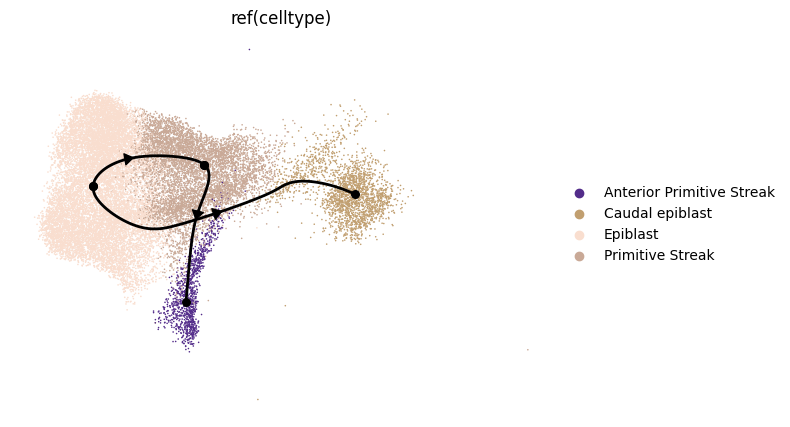

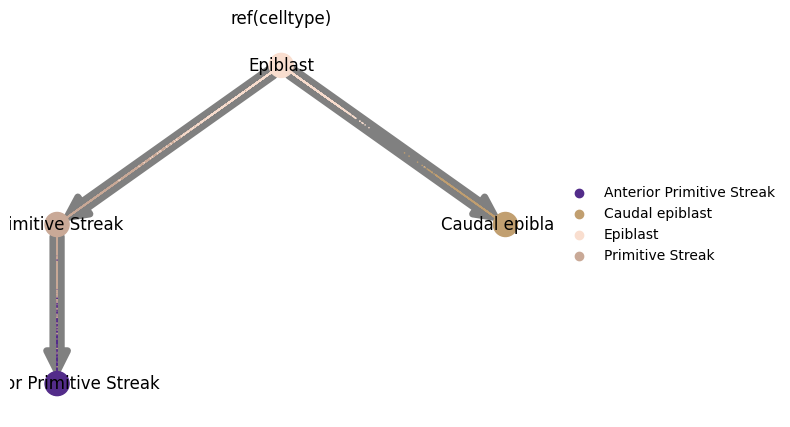

In [4]:
cafe.plot.plot_trajectory(fadata)
cafe.plot.plot_graph(fadata)

In [5]:
fadata.id = "gastrulation_blast"
fadata.check_result_dir()
fadata.write_trajectory_dict(model_name_list=["ref"])

DEBUG    |- write trajectory 'ref' to './.cafe/gastrulation_blast/trajectory_history/ref.pkl'                                                                                                           
